# XGBoost

Import the required libraries

In [1]:
%%time

import sys

# import imblearn
import numpy as np
import pandas as pd
import sklearn
import xgboost
# from imblearn.over_sampling import SMOTENC
from sklearn.metrics import accuracy_score, auc, classification_report, confusion_matrix, roc_curve
from sklearn.model_selection import GridSearchCV, train_test_split
from xgboost import XGBClassifier

__VERSIONS: list[str] = [
    f"python={sys.version.split()[0]}",
    # f"imbalanced-learn={imblearn.__version__}",
    f"numpy={np.__version__}",
    f"pandas={pd.__version__}",
    f"scikit-learn={sklearn.__version__}",
    f"xgboost={xgboost.__version__}",
]
__REQUIREMENTS_TXT: str = "\n".join(__VERSIONS)

# del imblearn
del sklearn
del xgboost

print(__REQUIREMENTS_TXT, "\n")

python=3.13.9
numpy=2.3.3
pandas=2.3.3
scikit-learn=1.7.2
xgboost=3.0.5 

CPU times: total: 4.02 s
Wall time: 25.6 s


In [2]:
import model_pipelines as mp

Define the variables

In [3]:
TARGET = "readmitted"
IDENTIFIERS = ["encounter_id", "patient_nbr"]

Skip the preprocessing (WS's notebook)

Skip transformation, but must explicitly cast categorical variables and use `enable_categorical=True`

In [4]:
data = pd.read_csv("preprocessed_data.csv").fillna("None")
for k in list(data.select_dtypes(include=["object"])) + ["admission_type_id", "discharge_disposition_id"]:
    data[k] = data[k].astype("category")

In [5]:
data

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,time_in_hospital,num_lab_procedures,num_procedures,...,metformin,glimepiride,glipizide,glyburide,pioglitazone,rosiglitazone,insulin,change,diabetesMed,readmitted
0,24437208,135,Caucasian,Female,[50-60),2,1,8,77,6,...,Steady,No,No,Change,No,No,Steady,Ch,Yes,1
1,29758806,378,Caucasian,Female,[50-60),3,1,2,49,1,...,No,No,No,No,No,No,No,No,No,0
2,189899286,729,Caucasian,Female,[80-90),1,3,4,68,2,...,Steady,No,No,No,No,No,No,No,Yes,0
3,64331490,774,Caucasian,Female,[80-90),1,1,3,46,0,...,Steady,No,No,Steady,No,No,No,Ch,Yes,0
4,14824206,927,AfricanAmerican,Female,[30-40),1,1,5,49,0,...,No,Steady,No,No,No,No,No,No,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70426,418513058,189351095,Caucasian,Female,[80-90),1,1,1,73,1,...,No,No,No,No,No,No,No,No,No,0
70427,359719064,189365864,Other,Male,[60-70),1,1,3,56,1,...,No,No,No,No,No,No,Steady,No,Yes,0
70428,338462954,189445127,Caucasian,Female,[80-90),1,1,3,39,0,...,Steady,No,Change,No,No,Steady,Change,Ch,Yes,0
70429,443811536,189481478,Caucasian,Female,[40-50),1,4,14,69,0,...,Change,No,No,Steady,No,No,Change,Ch,Yes,0


In [6]:
features = [col for col in data.columns if col not in IDENTIFIERS + [TARGET]]
X_train0, X_test, y_train0, y_test = mp.stratified_split(data, features=features, target=TARGET)

In [7]:
# %%time

X_train = X_train0
y_train = y_train0

# sm = SMOTENC(categorical_features="auto", random_state=42)
# X_train, y_train = sm.fit_resample(X_train0, y_train0)

In [8]:
def get_pos_weight(y_train: pd.Series | None=None) -> float:
    if y_train is None:
        y_train = globals()["y_train"]
    vc = y_train.value_counts()
    return float(vc[0] / vc[1])

def make_xgb(**kwargs) -> XGBClassifier:
    return XGBClassifier(random_state=42, enable_categorical=True, **kwargs)

def make_balanced_xgb(pos_weight: float | None=None, **kwargs) -> XGBClassifier:
    if pos_weight is None:
        pos_weight = get_pos_weight()
    return make_xgb(scale_pos_weight=pos_weight, **kwargs)

def train_xgb(
    xgb: XGBClassifier,
    features: list[str] | None=None,
    X_train: pd.DataFrame | None=None,
    y_train: pd.Series | None=None
) -> None:
    if X_train is None:
        X_train = globals()["X_train"]
    if y_train is None:
        y_train = globals()["y_train"]
    if features is None:
        features = X_train.columns
    xgb.fit(X_train[features], y_train)

def pred_xgb(
    xgb: XGBClassifier,
    features: list[str] | None=None,
    X_train: pd.DataFrame | None=None,
    X_test: pd.DataFrame | None=None,
    y_train: pd.Series | None=None,
    y_test: pd.Series | None=None
) -> dict[str, np.ndarray]:
    if X_train is None:
        X_train = globals()["X_train"]
    if X_test is None:
        X_test = globals()["X_test"]
    if y_train is None:
        y_train = globals()["y_train"]
    if y_test is None:
        y_test = globals()["y_test"]
    if features is None:
        features = X_train.columns
    y_pred_train = xgb.predict(X_train[features])
    y_proba_train = xgb.predict_proba(X_train[features])
    y_pred = xgb.predict(X_test[features])
    y_proba = xgb.predict_proba(X_test[features])
    return {
        "y_pred": y_pred,
        "y_proba": y_proba,
        "y_pred_train": y_pred_train,
        "y_proba_train": y_proba_train,
    }

def eval_xgb(
    xgb: XGBClassifier,
    y_pred: np.ndarray,
    y_proba: np.ndarray,
    y_pred_train: np.ndarray,
    y_proba_train: np.ndarray,
) -> dict[str, float]:
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred)
    train_rocauc = auc(*roc_curve(y_train, y_proba_train[:, 1])[:2])
    test_rocauc = auc(*roc_curve(y_test, y_proba[:, 1])[:2])
    print(f"\033[33mTrain: Accuracy = {train_accuracy:.6f} | AUC ROC = {train_rocauc:.6f}")
    print(f"\033[32mTest : Accuracy = {test_accuracy:.6f} | AUC ROC = {test_rocauc:.6f}\033[0m")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    return {
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "train_rocauc": train_rocauc,
        "test_rocauc": test_rocauc,
    }

In [9]:
xgbs = {
    "unbalanced": make_xgb(),
    "balanced": make_balanced_xgb(),
    # "balanced_maxdepth10": make_balanced_xgb(max_depth=10),
    # "balanced_regalpha5": make_balanced_xgb(reg_alpha=5),
    # "balanced_reglambda5": make_balanced_xgb(reg_lambda=5),
    # "balanced_regboth10": make_balanced_xgb(reg_alpha=10, reg_lambda=10),
    # "overbalanced": make_xgb(scale_pos_weight=pos_weight / 1.5),
}

preds = {}
metrics = {}
for k, xgb in xgbs.items():
    print(f"\033[36m{k}\033[0m")
    train_xgb(xgb)
    preds[k] = pred_xgb(xgb)
    metrics[k] = eval_xgb(xgb, **preds[k])

unbalanced
Train: Accuracy = 0.926695 | AUC ROC = 0.915607
Test : Accuracy = 0.908755 | AUC ROC = 0.609846
[[19159    83]
 [ 1845    43]]
              precision    recall  f1-score   support

           0       0.91      1.00      0.95     19242
           1       0.34      0.02      0.04      1888

    accuracy                           0.91     21130
   macro avg       0.63      0.51      0.50     21130
weighted avg       0.86      0.91      0.87     21130

balanced
Train: Accuracy = 0.850510 | AUC ROC = 0.943897
Test : Accuracy = 0.760625 | AUC ROC = 0.600728
[[15433  3809]
 [ 1249   639]]
              precision    recall  f1-score   support

           0       0.93      0.80      0.86     19242
           1       0.14      0.34      0.20      1888

    accuracy                           0.76     21130
   macro avg       0.53      0.57      0.53     21130
weighted avg       0.86      0.76      0.80     21130



=== Train Set Classification Report ===
              precision    recall  f1-score   support

           0       0.99      0.85      0.91     44896
           1       0.36      0.88      0.51      4405

    accuracy                           0.85     49301
   macro avg       0.67      0.86      0.71     49301
weighted avg       0.93      0.85      0.88     49301

=== Test Set Classification Report ===
              precision    recall  f1-score   support

           0       0.93      0.80      0.86     19242
           1       0.14      0.34      0.20      1888

    accuracy                           0.76     21130
   macro avg       0.53      0.57      0.53     21130
weighted avg       0.86      0.76      0.80     21130

=== Train Metrics ===
Accuracy: 0.8505, Precision: 0.9305, Recall: 0.8505, F1-score: 0.8761, ROC AUC: 0.9439
=== Test Metrics ===
Accuracy: 0.7606, Precision: 0.8553, Recall: 0.7606, F1-score: 0.8005, ROC AUC: 0.6007
=== Confusion Matrix ===


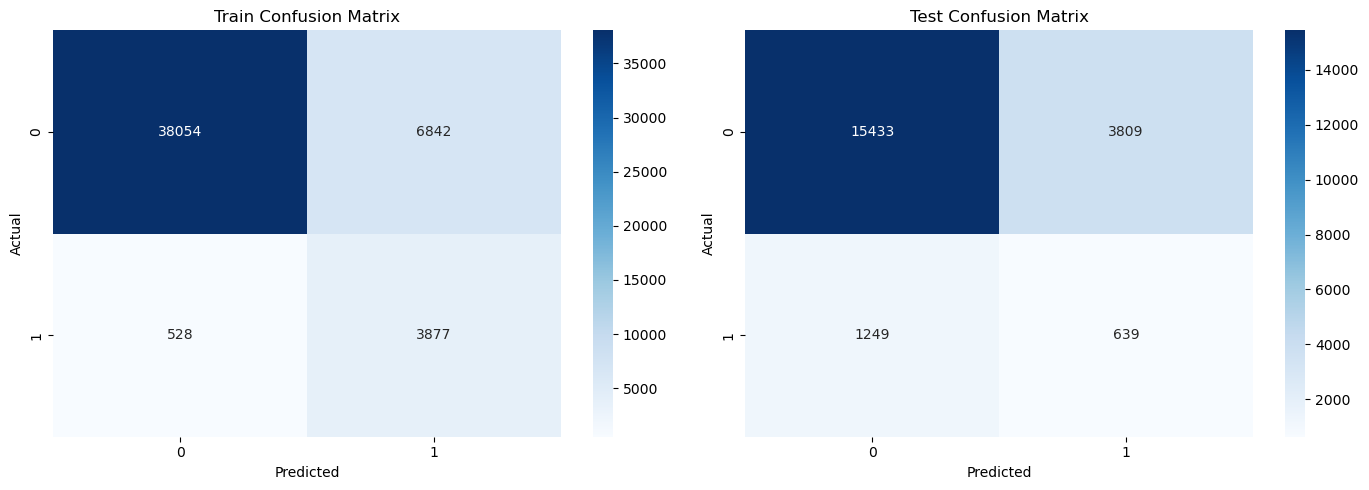

=== ROC AUC Curve ===


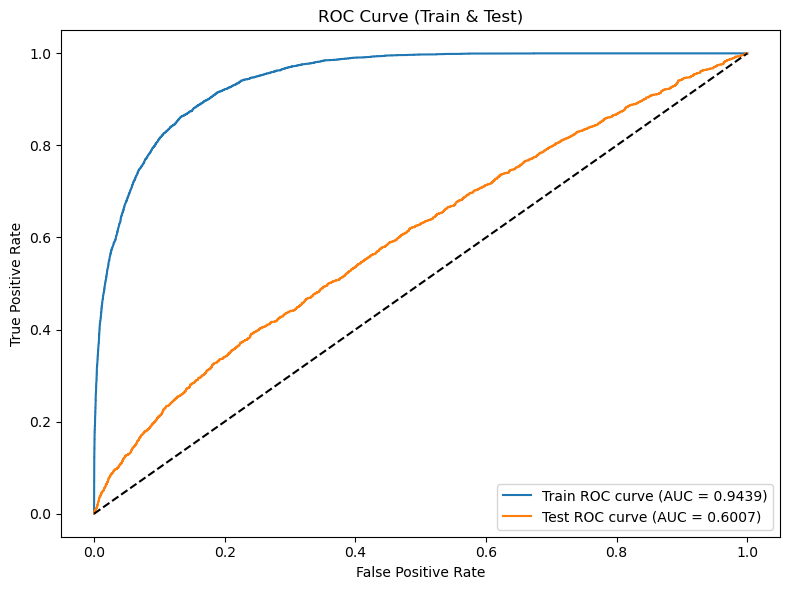

In [10]:
mp.evaluate_model(y_test, y_train=y_train, **preds["balanced"])

In [11]:
%%time

param_grid = {
    "n_estimators": [25, 50, 75, 100],
    "max_depth": [5, 6, 7],
    # "learning_rate": [0.3, 0.4, 0.5],
    "reg_alpha": [50, 75, 100],
    "reg_lambda": [50, 75, 100],
}

xgb_base = make_balanced_xgb()

grid_search = GridSearchCV(estimator=xgb_base, param_grid=param_grid, scoring="average_precision", cv=5, verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'max_depth': 5, 'n_estimators': 50, 'reg_alpha': 75, 'reg_lambda': 75}
CPU times: total: 17.3 s
Wall time: 1min 34s


In [12]:
k = X_train.shape[1]
preds2 = {k: pred_xgb(best_xgb)}
metrics2 = {k: eval_xgb(best_xgb, **preds2[k])}

Train: Accuracy = 0.678708 | AUC ROC = 0.726694
Test : Accuracy = 0.657123 | AUC ROC = 0.653294
[[12860  6382]
 [  863  1025]]
              precision    recall  f1-score   support

           0       0.94      0.67      0.78     19242
           1       0.14      0.54      0.22      1888

    accuracy                           0.66     21130
   macro avg       0.54      0.61      0.50     21130
weighted avg       0.87      0.66      0.73     21130



In [13]:
def get_top_features(xgb: XGBClassifier, drop_scores: bool=True) -> list[str | tuple[str, float]]:
    top_features = sorted(xgb.get_booster().get_score(importance_type="gain").items(), key=lambda t: t[1], reverse=True)
    if drop_scores:
        top_features = [name for name, score in top_features]
    return top_features

get_top_features(best_xgb, drop_scores=False)

[('discharge_disposition_id', 98.22029876708984),
 ('number_inpatient', 61.684391021728516),
 ('diag_1', 22.765750885009766),
 ('number_diagnoses', 18.508193969726562),
 ('number_emergency', 17.653444290161133),
 ('diabetesMed', 15.269122123718262),
 ('admission_type_id', 15.054313659667969),
 ('insulin', 14.860517501831055),
 ('glipizide', 13.596966743469238),
 ('age', 12.618110656738281),
 ('glyburide', 12.134937286376953),
 ('metformin', 12.07783031463623),
 ('diag_2', 11.120902061462402),
 ('time_in_hospital', 10.67457103729248),
 ('diag_3', 9.964569091796875),
 ('gender', 9.802114486694336),
 ('num_lab_procedures', 9.09024429321289),
 ('race', 8.45323371887207),
 ('num_medications', 8.220534324645996),
 ('num_procedures', 8.083765983581543),
 ('number_outpatient', 7.893832206726074),
 ('rosiglitazone', 7.774824619293213),
 ('max_glu_serum', 7.616323947906494),
 ('A1Cresult', 7.499892711639404),
 ('change', 6.958254337310791),
 ('pioglitazone', 5.649150371551514),
 ('glimepiride', 

## (5-)Stepwise reduction from top 20 predictors

In [14]:
def metrics_argmax(metrics: dict[str, dict[str, float]], metric: str="roc_diff") -> str:
    if metric == "roc_diff":
        return min(metrics, key=lambda k: abs(metrics[k]["test_rocauc"] - metrics[k]["train_rocauc"]))
    return max(metrics, key=lambda k: metrics[k][metric])

In [15]:
old_xgb = best_xgb
for n in [20, 15, 10, 5]:
    topn_features = get_top_features(old_xgb)[:n]
    print(f"Top {n}: {topn_features}")
    xgb = make_balanced_xgb(**grid_search.best_params_)
    train_xgb(xgb, features=topn_features)
    preds2[n] = pred_xgb(xgb, features=topn_features)
    metrics2[n] = eval_xgb(xgb, **preds2[n])
    old_xgb = xgb
    print()

Top 20: ['discharge_disposition_id', 'number_inpatient', 'diag_1', 'number_diagnoses', 'number_emergency', 'diabetesMed', 'admission_type_id', 'insulin', 'glipizide', 'age', 'glyburide', 'metformin', 'diag_2', 'time_in_hospital', 'diag_3', 'gender', 'num_lab_procedures', 'race', 'num_medications', 'num_procedures']
Train: Accuracy = 0.676497 | AUC ROC = 0.722999
Test : Accuracy = 0.654993 | AUC ROC = 0.649231
[[12814  6428]
 [  862  1026]]
              precision    recall  f1-score   support

           0       0.94      0.67      0.78     19242
           1       0.14      0.54      0.22      1888

    accuracy                           0.65     21130
   macro avg       0.54      0.60      0.50     21130
weighted avg       0.87      0.65      0.73     21130


Top 15: ['discharge_disposition_id', 'number_inpatient', 'diag_1', 'number_emergency', 'diabetesMed', 'number_diagnoses', 'age', 'insulin', 'time_in_hospital', 'glipizide', 'admission_type_id', 'glyburide', 'diag_2', 'metformin'

Top 27 (all) predictors maximizes test ROC AUC.
=== Train Set Classification Report ===
              precision    recall  f1-score   support

           0       0.95      0.68      0.79     44896
           1       0.17      0.65      0.26      4405

    accuracy                           0.68     49301
   macro avg       0.56      0.66      0.53     49301
weighted avg       0.88      0.68      0.75     49301

=== Test Set Classification Report ===
              precision    recall  f1-score   support

           0       0.94      0.67      0.78     19242
           1       0.14      0.54      0.22      1888

    accuracy                           0.66     21130
   macro avg       0.54      0.61      0.50     21130
weighted avg       0.87      0.66      0.73     21130

=== Train Metrics ===
Accuracy: 0.6787, Precision: 0.8813, Recall: 0.6787, F1-score: 0.7471, ROC AUC: 0.7267
=== Test Metrics ===
Accuracy: 0.6571, Precision: 0.8657, Recall: 0.6571, F1-score: 0.7302, ROC AUC: 0.6533
==

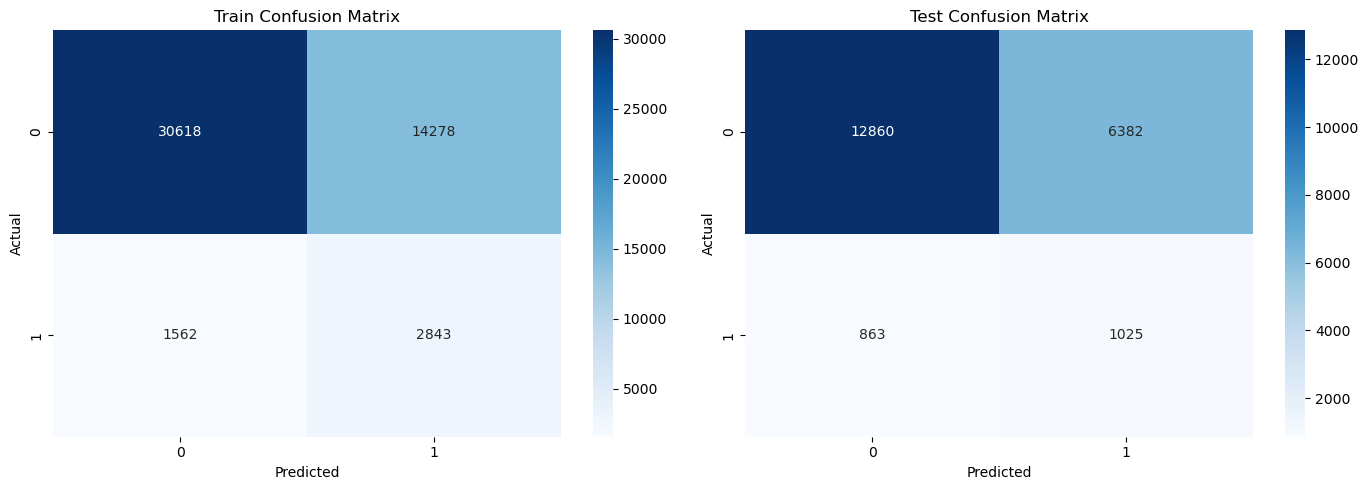

=== ROC AUC Curve ===


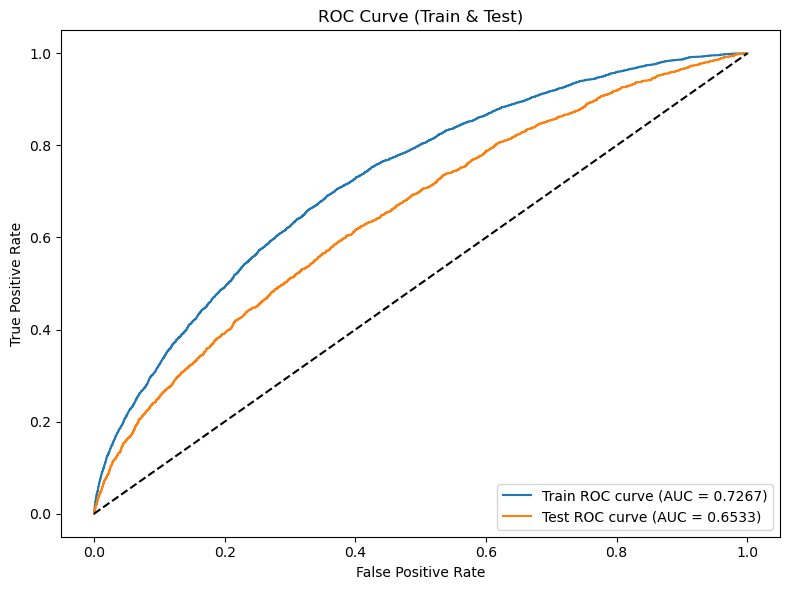

In [16]:
k = metrics_argmax(metrics2, metric="test_rocauc")
k2 = k if k < X_train.shape[1] else f"{k} (all)"
print(f"\033[36mTop {k2} predictors maximizes test ROC AUC.\033[0m")
mp.evaluate_model(y_test, y_train=y_train, **preds2[k])

Top 5 predictors minimizes train-test ROC AUC difference.
=== Train Set Classification Report ===
              precision    recall  f1-score   support

           0       0.94      0.68      0.79     44896
           1       0.14      0.54      0.23      4405

    accuracy                           0.67     49301
   macro avg       0.54      0.61      0.51     49301
weighted avg       0.87      0.67      0.74     49301

=== Test Set Classification Report ===
              precision    recall  f1-score   support

           0       0.94      0.68      0.79     19242
           1       0.14      0.53      0.22      1888

    accuracy                           0.66     21130
   macro avg       0.54      0.60      0.50     21130
weighted avg       0.87      0.66      0.74     21130

=== Train Metrics ===
Accuracy: 0.6706, Precision: 0.8673, Recall: 0.6706, F1-score: 0.7404, ROC AUC: 0.6593
=== Test Metrics ===
Accuracy: 0.6646, Precision: 0.8650, Recall: 0.6646, F1-score: 0.7358, ROC AUC:

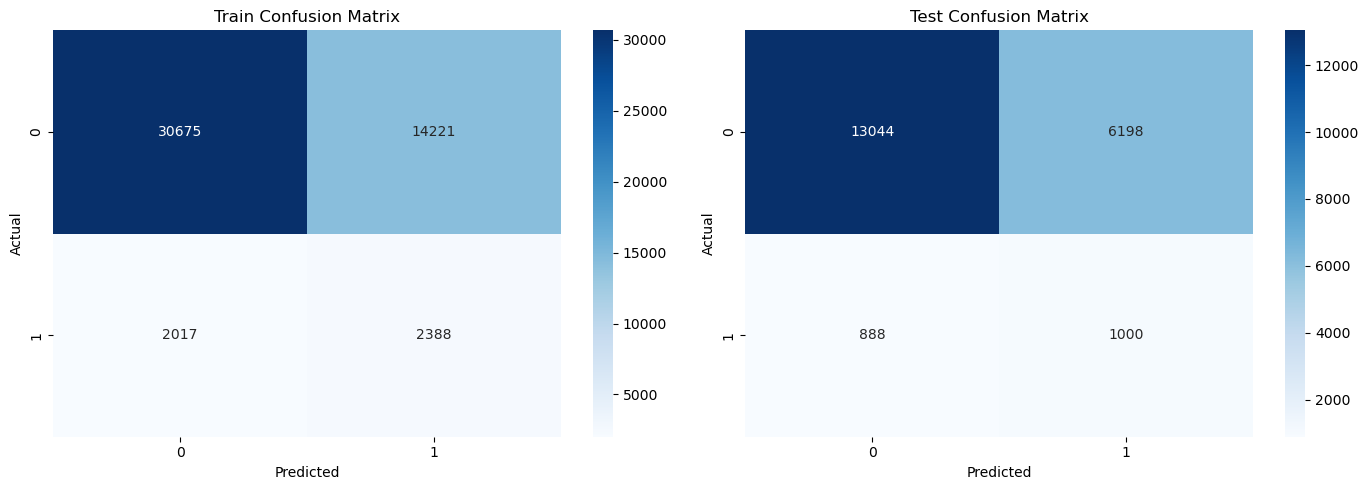

=== ROC AUC Curve ===


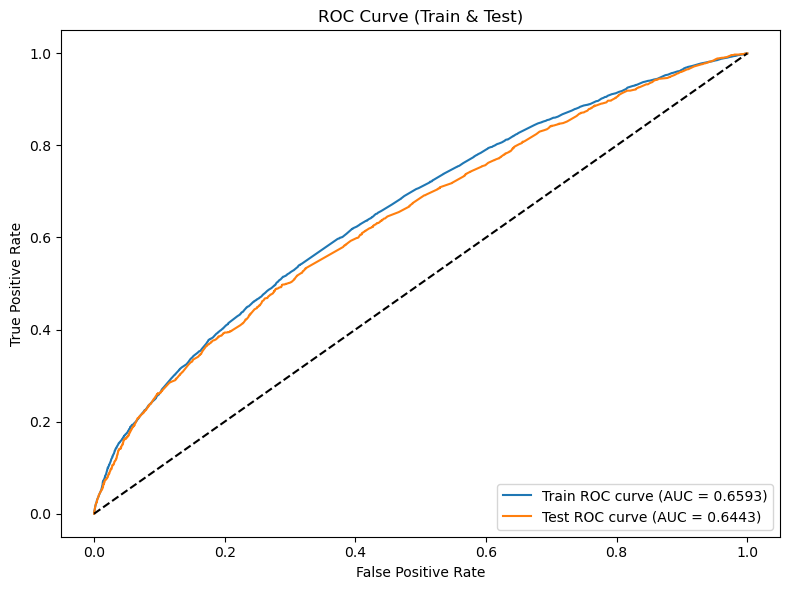

In [17]:
k = metrics_argmax(metrics2, metric="roc_diff")
k2 = k if k < X_train.shape[1] else f"{k} (all)"
print(f"\033[36mTop {k2} predictors minimizes train-test ROC AUC difference.\033[0m")
mp.evaluate_model(y_test, y_train=y_train, **preds2[k])